# Utilizing Rule-Based Semantic Extraction and Text Parsing to Automate Scoring Cards in *Magic: The Gathering*
### IMT 575 - Spring 2026

## Summary
This project presents a rule-based system for quantifying the power level of creature cards in *Magic: The Gathering* by extracting structured features from Oracle text and card metadata. The system parses card text to identify gameplay-relevant mechanics, incorporates attributes such as mana value, power, toughness, and keyword abilities, and combines these features into a weighted scoring function to produce a continuous power score for each card.

To evaluate the effectiveness of the proposed approach, we compare it against general-purpose NLP baselines, including TF-IDF and embedding-based models, applied to the same task of predicting card power scores. The results indicate that domain-specific rule-based parsing significantly outperforms generic text-based representations, highlighting the importance of incorporating structured game knowledge when modeling *Magic: The Gathering* card strength.

Applying the system to a dataset of creature cards reveals a consistent upward trend in estimated power levels over time, providing quantitative evidence for creature power creep in modern card design.

## Introduction and Background
*Magic: The Gathering* is a popular card game, played worldwide by millions of players. First released in 1993, its 30+ year history has led to many thousands of unique cards being printed across its lifetime, all of various types and effects. The game's longevity, complex but rewarding structure, and its relatively freeform play expression has attracted many different kinds of players, both casual and competitive.

One of the key methods of engagement with the game, regardless of the kind of player one is, is the practice of card evaluation. Cards in *Magic: The Gathering* have different abilities, and this affects how powerful they might be when used in gameplay contexts. By taking a card and reading the text, one makes a judgment on how powerful they perceive that card to be. The result of evaluation is often colloquially referred to as the card's *power level*.

In recent years, there has been growing sentiment among players that the design of recent *Magic: The Gathering* sets has resulted in cards becoming too powerful too quickly, especially compared to historical examples. This in turn has aggravated a phenomenon known as *power creep*. While no formal definition of power creep exists, this project assumes the following definition:

**Power creep**: an observable trend of the increasing power level, complexity, or both in a game system over time.

In the context of trading card games, power creep is widely considered to be an unavoidable reality, due to factors such as design space, distribution model, and player sentiment. However, there remains arguments that the *degree* of power creep has gone too far in recent years for *Magic*, which in turn negatively affects the play experience.

While many players would regard this sentiment as an accurate reflection of the current game's design direction, it remains unclear just *how* severe the effects of power creep have been on the design of recent cards in *Magic*. This is partly due to the fact that determining a card's power level is often an informal exercise, without clear quantifiable values. This is not to say there cannot be consensus about a card's power level, but the lack of quantifiable metrics remains a problem.

## Motivation
Discussions surrounding power creep and power levels in *Magic: The Gathering* often stem from individual player experience and anecdotal evidence. While many players agree that modern cards are generally stronger and more mechanically complex than their historical counterparts, there are relatively few quantitative methods for measuring the magnitude of this change. As a result, debates regarding the severity of power creep frequently rely on subjective judgments rather than reproducible metrics.

<div style="display: flex; justify-content: center; gap: 16px; align-items: flex-start;">

  <figure style="margin: 0; text-align: center;">
    <img src="assets/card_images/ice-225-aurochs.jpg" width="250">
    <figcaption><i>1995</i></figcaption>
  </figure>

  <figure style="margin: 0; text-align: center;">
    <img src="assets/card_images/blb-2-beza-the-bounding-spring.jpg" width="250">
    <figcaption><i>2024</i></figcaption>
  </figure>

</div>

<p style="max-width: 800px; margin: 16px auto; text-align: left; font-size: 16px">
  <em>On the left is a card from 1995; on the right is a card from 2024. Note that on the left card, the italicized text is considered "flavor text" and has no bearing on gameplay, simply included for lore and worldbuilding.</em>
</p>

Developing a systematic method for evaluating card strength has value for several groups. Players can use quantitative measures to better understand long-term design trends, while game designers can use such analyses to examine how card power and complexity evolve over time. More broadly, *Magic: The Gathering* provides an interesting case study for applying natural language processing and feature engineering techniques to a domain in which structured game mechanics are encoded within natural-language text.

This project, `mtg-mechanics-parser`, aims to provide a quantitative framework for evaluating creature cards in *Magic: The Gathering*. To accomplish this, we construct a rule-based parsing system that extracts gameplay-relevant mechanics from card text and converts them into structured numerical features. By assigning weighted values to these features, we can produce an approximate power score that can be analyzed across the game's history. The resulting dataset enables large-scale investigation of power-level trends and provides a foundation for quantitatively studying power creep in *Magic: The Gathering*.

## Key Game Concepts and Terminology
To facilitate understanding for readers unfamiliar with *Magic: The Gathering*, several game-specific terms used throughout this report are defined below.

**Creature Card**: A card type that can participate directly in combat. Creatures are the primary focus of this project.

**Power/Toughness**: Numerical values printed on creature cards representing their offensive and defensive capabilities, respectively.

**Mana Value**: The total resource cost required to cast a card. In general, cards with higher mana values are expected to have stronger effects.

**Set**: A game expansion featuring many new cards for players to collect and play with. Cards within sets are usually similar in thematic or mechanical context.

**Oracle Text**: The official rules text associated with a card. Oracle text precisely describes a card's gameplay effects and serves as the primary source used for feature extraction in this project.

**Keyword**: A standardized term or phrase in *Magic: The Gathering* Oracle text that represents a discrete gameplay mechanic. In this project, keywords are treated as structured, extractable units that correspond to either abilities (e.g. *flying, trample*) or actions (e.g. *exile, discard*).

Due to the structure of the dataset used in this project, keyword abilities are already provided as a pre-parsed feature and are represented explicitly as a list associated with each card. These keyword abilities are incorporated directly into the feature set used for scoring.

In contrast, keyword actions are not assumed to be pre-extracted and are instead identified during the parsing of Oracle text as part of the rule-based feature extraction pipeline.

**Power Level**: An informal measure of a card's perceived strength. Almost always a qualitative measure.

**Power Score**: A quantitative metric produced by our system that estimates the overall strength of a creature card based on its characteristics and extracted mechanics.

  <figure style="margin: 0; text-align: center;">
    <img src="assets/diagrams/Parts_of_a_Magic_card.png" width="800">
    <figcaption><i>Figure 1: Different parts of a Magic card</i></figcaption>
  </figure>

## Problem Definition
Creature cards in *Magic: The Gathering* contain natural-language rules text that describes their gameplay effects. Although players routinely evaluated the strength of these cards, such evaluations are typically qualitative and difficult to compare across large numbers of cards.

Previously, we were able to hand score creature cards using a written criteria and calculate their power manually. However, this approach had severe limitations, namely its inability to scale to larger datasets and the reliance on human judgment for scoring.

These problems are addressed by this project via the automatic extraction of gameplay-relevant mechanics from creature card text and the conversion of those mechanics into structured numerical features. These features are then combined into a weighted scoring system that estimates a card's overall power level. The resulting scores can be used to analyze historical trends in creature design and investigate the extent of power creep throughout the game's history.

## Related Work
Directly related work on quantitative evaluations of *Magic: The Gathering* card power is limited. While there is a substantial body of informal analysis and community-driven evaluation of card strength, relatively few academic or formal studies attempt to model power creep or card strength in a systematic, reproducible manner.

One of the few directly relevant efforts is a recent study by Magruder (2022) that proposes a conservative method for measuring power creep through the concept of "strictly better" cards. In this framework, a card is considered strictly better than another if it satisfies a set of structural conditions, including mana efficiency, equivalence of rules text, and shared type characteristics. The author then uses the presence of such relationships across printings as a lower-bound indicator of power creep over time. While this approach provides a principled and interpretable measure of power escalation, it is inherently binary and intentionally conservative, capturing only clear-cut dominance relationships between cards.

This work instead operates in a more continuous feature space by extracting structured mechanical information from Oracle text and encoding it into numerical features. This allows for finer-grained representation of card strength and enables large-scale temporal analysis beyond strict dominance relationships.

## Our Data
The dataset used in this project is based on an existing collection of 857 *Magic: The Gathering* creature cards from a prior study, which includes precomputed power score values (`points`). This dataset is augmented with structured metadata from Scryfall, a comprehensive database of official *Magic* card information.

The merged dataset includes core card attributes such as mana value (converted mana cost), Oracle text, power and toughness values, keyword annotations, set information, and card name. Additional metadata from Scryfall, including Oracle identifiers and release year, is incorporated to support temporal analysis and ensure consistent card identification across printings.

To support numerical analysis, power and toughness values are converted into numeric representations. Missing or non-standard values are handled through standard conversion procedures to ensure compatibility with downstream modeling. Keywords are also normalized into structured list format to facilitate feature extraction.

## Approach
This project develops a rule-based pipeline for extracting structured gameplay features from *Magic: The Gathering* creature cards and converting them into a quantitative estimate of card strength, referred to as a *power score*. The system is designed to operate on Oracle text and associated card metadata, producing a consistent numerical representation of card power that can be used for analysis.

### Scope of Analysis
This work focuses exclusively on creature cards. This design choice is motivated by the fact that creature cards provide a relatively standardized structure for quantitative analysis, including explicit power and toughness values that support direct comparison across cards. Additionally, creature cards tend to exhibit more consistent templating in Oracle text compared to other card types, making them more suitable for rule-based parsing of gameplay mechanics.

By restricting the analysis to creatures, we ensure that all evaluated entities share a common evaluation framework based on combat relevance and stat-based interaction, which improves comparability across the dataset.

### Feature Representation
Each card is represented using a combination of structured metadata and extracted textual features. Core inputs include mana value (converted mana cost), power, toughness, Oracle text, keyword abilities, and card metadata.

Power and toughness values are converted into numeric representations to enable downstream computation. Keyword abilities are represented as a pre-parsed list feature when available in the dataset. In addition, Oracle text is processed to extract keyword actions and other rule-based mechanical indicators using a rule-based parsing system.

The resulting feature set forms the basis for a structured representation of each card's gameplay characteristics.

The overall pipeline is illustrated in Figure 2.

<center>

<img src='assets/diagrams/pipeline_figure_1.png' width=800>

</center>

### Power Scoring Function

To quantify card strength, we define a power score as a weighted combination of extracted features derived from base statistics, keyword abilities, and Oracle text-based mechanics. This score aggregates contributions from combat statistics, mechanical effects, and structured gameplay interactions into a single continuous value.


$$
\text{PowerScore}(c) = \mathbf{w}^\top \mathbf{f}(c)
$$


where $\mathbf{f}(c)$ represents the feature vector extracted from card $c$, and $\mathbf{w}$ represents a set of manually defined weights over feature components. Each element of the feature vector corresponds to a specific gameplay mechanic extracted from the card, such as combat statistics, keyword abilities, card advantage effects, or removal effects. Table 1 summarizes the primary feature categories used in the scoring system.

#### Table 1. Feature Categories Used in Power Score Computation

| Feature Group | Examples | Scoring Approach |
|--------------|----------|------------------|
| Base Statistics | Power, Toughness | Linear contribution from combat statistics, with additional bonuses for high power values. |
| Keyword Abilities | Flying, Trample, Haste, Hexproof | +1 per keyword, with additional bonuses or penalties for selected keywords. |
| Triggered Abilities | ETB effects, attack triggers, upkeep triggers | Fixed contribution per detected trigger. |
| Activated Abilities | Activated effects with or without activation costs | Contribution based on presence and repeatability of the ability. |
| Token Creation | Creature token generation | Score derived from generated token statistics. |
| Card Advantage | Draw effects, discard effects, recursion, impulse draw | Contribution based on net card advantage (cards drawn or opponent cards discarded). |
| Removal and Interaction | Destroy, bounce, exile, −X/−X effects | Contributions based on the type and scope of interaction. |
| Mana Effects | Mana generation, mana cost reduction | Score proportional to mana produced or reduced. |
| Damage Effects | Direct damage to opponents | Fixed contribution per damaging effect. |
| Global Effects | Effects impacting multiple creatures or players | Additional bonus for board-wide influence. |
| Special/Misc. Mechanics | +1/+1 counters, search effects | Special-cased miscellaneous effects. |

#### Table 2. Core Feature Weights

| Feature | Weight |
|----------|---------|
| Power | +1 per power |
| Toughness | +1 per toughness |
| Keyword Ability | +1 per keyword |
| Enter-the-Battlefield Trigger | +1 |
| Repeatable Trigger | +1 |
| Activated Ability (limited) | +1 |
| Activated Ability (unlimited) | +2 |
| Card Advantage | +1 per net advantage |
| Single-Target Removal | +1 |
| Mass Removal | +2 |
| Mana Production | +1 per mana generated |
| Cost Reduction | +1 per cost reduced |
| Direct Damage | +1 |
| Global Effect | +1 |
| Special/Misc. Effects | +1 |

The weighting scheme is adapted from a previously developed creature evaluation rubric and expanded to support automated extraction of mechanics from Oracle text. Individual feature weights are manually defined based on their expected gameplay impact.

The scoring system is designed to be consistent and reproducible across all cards in the dataset. Rather than attempting to perfectly model subjective human evaluation, the objective is to construct a stable metric that preserves relative differences in card strength and enables large-scale comparative analysis.

### Design Rationale and Constraints
The system prioritizes consistency over perfect semantic accuracy. As a result, certain simplifications are introduced. For example, the degree of strength of most individual abilities is not explicitly modeled, and contextual conditions or costs associated with abilities are not fully represented in the scoring function. Additionally, some components of the feature set are derived from manually curated rules, which may introduce minor inconsistencies.

Despite these limitations, the resulting framework provides a scalable and uniform method for evaluating creature cards, enabling systematic analysis of power trends over time.

## Experiments
### Overview
This project evaluates whether structured gameplay features can be automatically extracted from *Magic: The Gathering* Oracle text and used to approximate a ground-truth card power score. We design a rule-based parsing and scoring pipeline that transforms raw data into structured numerical features, and compare these derived representations against precomputed reference labels.

Rather than directly training a model end-to-end from raw text, we first construct an interpretable feature extraction system grounded in game mechanics, and then assess how well these engineered signals align with the provided power score.

### Dataset Construction
The dataset is derived from a collection of 857 *Magic: The Gathering* creature cards, augmented with structured metadata from the Scryfall API. Each card includes Oracle text, mana value (converted mana cost), power and toughness values, keyword annotations, set information, and release metadata.

A preprocessing pipeline is used to:
- Deduplicate cards across printings, prioritizing the earliest available versions
- Normalize Oracle text and keyword fields
- Convert power and toughness into numeric representations
- Extract temporal features such as release year

The final dataset is merged with precomputed ground-truth power scores (`points`), which serve as supervision signals for evaluation.

### Feature Extraction Pipeline
We construct a rule-based feature engineering system that maps raw card attributes into structured gameplay signals.

**Oracle Text Processing**
Oracle text is preprocessed using normalization routines that standardize syntax and remove irrelevant formatting, and prepare text for keyword extraction and vectorization.

**Keyword Parsing**
Card keywords (e.g. Flying, Trample, Deathtouch) are extracted and normalized into structured binary features. These mechanics are treated as interpretable gameplay signals that contribute to card strength.

**Numeric Feature Construction**
We derive numeric attributes including:
- Mana value (CMC)
- Power and toughness (converted to numeric form with fallback handling)

These features form a structured representation of each creature's baseline profile.

### Rule-Based Power/Toughness Scoring
To capture baseline combat strength independent of text-based abilities, we define a deterministic scoring function over power and toughness:
- Base score is computed as the sum of power and toughness
- Additional bonuses are applied for high-power thresholds (e.g. large creatures receive incremental boosts)

This produces a `PT score`, representing raw combat efficiency before considering abilities or keyword effects.

We then compute a residual signal:
- Difference between ground-truth power score and `PT score`

This isolates the contribution of Oracle text and keyword mechanics beyond raw statistics.

### Experimental Setup
The experimental pipeline proceeds in two stages:

**1. Feature Pipeline Construction**
We transform raw card data into structured representations using:
- Text preprocessing and keyword parsing
- Numeric feature normalization
- Rule-based PT scoring

**2. Ground Truth Comparison**
Each card's engineered features are compared against the ground-truth power score. This allows us to:
- Measure how much variance is explained by baseline statistics (power, toughness)
- Isolate the contribution of ability-driven features (keywords and Oracle text structure)

**3. Feature Baselines (NLP Comparison)**
We construct additional text-based baselines using:
- TF-IDF vectorization
- Universal Sentence Encoder embeddings

These representations are used as alternative feature encodings of Oracle text for comparison against the rule-based parser pipeline.

In [1]:
import pandas as pd
import numpy as np

from mtg_parser.utils.paths import PROCESSED_DIR
from mtg_parser.data.extract_creatures import build_creatures_dataset
from mtg_parser.data.build_dataset import save_cleaned_dataset

%load_ext autoreload
%autoreload 2

In [2]:
# Build creatures dataset from default-cards
build_creatures_dataset()

# Save the cleaned dataset
save_cleaned_dataset()

[pipeline] Default-cards dataset already exists.
[pipeline] Creatures dataset already exists.
[cleaning] Missing oracle_id rows: 0
[cleaning] Duplicate values in rows: 0
[builder] Saved combined_points_cleaned.csv to /data/processed/


## Parser vs NLP Baselines

The goal is to compare our symbolic parsing pipeline against two general NLP baselines: TF-IDF and Universal Sentence Encoder embeddings. The hand-scored `points` column includes power/toughness, keyword value, and oracle-text effects, so we subtract the power/toughness component before modeling.

This gives us `points_minus_pt`, a target that focuses the comparison on the mechanics expressed in card text and keywords.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)


from mtg_parser.utils.text_preprocessing import preprocess_oracle_text
from mtg_parser.parsing.keyword_router import parse_keywords_column
from mtg_parser.pipeline.orchestrator import build_card_ability_bundle
from mtg_parser.features.card_features import build_card_features
from mtg_parser.scoring.card_scorer import score_card
from mtg_parser.scoring.pt_scorer import score_pt

cards_df = pd.read_csv(PROCESSED_DIR / "combined_points_cleaned.csv")
cards_df["oracle_text"] = cards_df["oracle_text"].fillna("")
cards_df = parse_keywords_column(cards_df)

cards_df["oracle_text_preprocessed"] = cards_df["oracle_text"].map(preprocess_oracle_text)
cards_df["pt_score"] = cards_df.apply(
    lambda row: score_pt(row["power_numeric"], row["toughness_numeric"], row["power_from_cmc"]),
    axis=1,
)
cards_df["points_minus_pt"] = cards_df["points"] - cards_df["pt_score"]

cards_df[["name", "points", "pt_score", "points_minus_pt", "oracle_text_preprocessed"]].head()

,name,points,pt_score,points_minus_pt,oracle_text_preprocessed
0,Benalish Hero,3,2.0,1.0,Banding
1,Merfolk of the Pearl Trident,2,2.0,0.0,
2,Goblin Balloon Brigade,3,2.0,1.0,{R}: This creature gains flying until end of t...
3,Birds of Paradise,4,1.0,3.0,Flying\n{T}: Add one mana of any color.
4,Will-o'-the-Wisp,3,1.0,2.0,Flying \n{B}: Regenerate this creature.


### Rule-Based Parser Scores

Our pipeline splits oracle text into ability blocks, classifies those abilities, extracts mechanics features, and applies our scoring weights. To compare against the NLP baselines, we evaluate the parser's mechanics score only: ability score plus keyword score.

In [4]:
parser_rows = []

for idx, row in cards_df.iterrows():
    bundle = build_card_ability_bundle(row)
    card_features = build_card_features(bundle, row)
    score = score_card(card_features)

    parser_rows.append({
        "idx": idx,
        "oracle_id": row["oracle_id"],
        "name": row["name"],
        "set": row["set"],
        "manual_points": row["points"],
        "points_minus_pt": row["points_minus_pt"],
        "parser_ability_score": score.ability,
        "parser_keyword_score": score.keyword,
        "parser_pt_score": score.pt,
        "parser_mechanics_score": score.ability + score.keyword,
        "parser_total_score": score.total,
        "parser_mechanics_residual": row["points_minus_pt"] - (score.ability + score.keyword),
        "parser_total_residual": row["points"] - score.total,
    })

parser_df = pd.DataFrame(parser_rows).set_index("idx")

parser_df.head()

,oracle_id,name,set,manual_points,points_minus_pt,parser_ability_score,parser_keyword_score,parser_pt_score,parser_mechanics_score,parser_total_score,parser_mechanics_residual,parser_total_residual
idx,,,,,,,,,,,,
0,4c81cfb7-8765-4e28-ae33-4287fa9a86cc,Benalish Hero,lea,3,1.0,0,1,2.0,1,3.0,0.0,0.0
1,218d9277-c179-4de3-9c7f-79b5a6d4fa38,Merfolk of the Pearl Trident,lea,2,0.0,0,0,2.0,0,2.0,0.0,0.0
2,10bc98b0-3fdc-46d1-8d3b-6d160e9dd62f,Goblin Balloon Brigade,lea,3,1.0,1,0,2.0,1,3.0,0.0,0.0
3,d3a0b660-358c-41bd-9cd2-41fbf3491b1a,Birds of Paradise,lea,4,3.0,2,1,1.0,3,4.0,0.0,0.0
4,8b60fcfe-fb90-4a00-a708-25b59bfc9b5a,Will-o'-the-Wisp,lea,3,2.0,1,1,1.0,2,3.0,0.0,0.0


### Shared Train/Test Split

The NLP models use an 80/20 train/test split. The parser is rule-based and does not train, but we evaluate it on the same test rows so all reported metrics are directly comparable.

In [5]:
train_idx, test_idx = train_test_split(
    cards_df.index,
    test_size=0.2,
    random_state=42,
)

train_df = cards_df.loc[train_idx]
test_df = cards_df.loc[test_idx]

y_train = train_df["points_minus_pt"]
y_test = test_df["points_minus_pt"]

len(train_df), len(test_df)

(685, 172)

### TF-IDF Baseline

The TF-IDF baseline represents oracle text with word and phrase frequency features, then uses Ridge regression to predict `points_minus_pt`. This tests how far a lightweight text model can get without explicit Magic rules or mechanic-specific parsing.

In [6]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(train_df["oracle_text_preprocessed"])
X_test_tfidf = tfidf.transform(test_df["oracle_text_preprocessed"])

tfidf_model = Ridge(alpha=1.0)
tfidf_model.fit(X_train_tfidf, y_train)

tfidf_preds = tfidf_model.predict(X_test_tfidf)

tfidf_results = test_df[["oracle_id", "name", "set", "points_minus_pt"]].copy()
tfidf_results["tfidf_pred"] = tfidf_preds
tfidf_results["tfidf_residual"] = tfidf_results["points_minus_pt"] - tfidf_results["tfidf_pred"]

tfidf_results.head()

,oracle_id,name,set,points_minus_pt,tfidf_pred,tfidf_residual
712,33f4fcd5-4eea-4146-a564-da5511a8ee0a,Thought Shucker,blb,3.0,2.710133,0.289867
603,b2b76070-f103-4f83-ad21-119e6352f2cd,Glowstone Recluse,iko,4.0,3.250533,0.749467
120,b373e978-c58b-465a-b68a-9d4acec9dce0,Dwarven Blastminer,ons,3.0,2.255128,0.744872
208,17191fa9-e956-4f46-b541-465790125b6b,Hystrodon,ons,4.0,2.991103,1.008897
380,3f15349a-6ac6-4091-95a3-ae9f593e4650,Surgespanner,lrw,2.0,1.918170,0.081830


### Universal Sentence Encoder Baseline

The embedding baseline uses Universal Sentence Encoder, matching the embedding-style approach discussed for the presentation comparison. Each card's oracle text is converted into a dense vector, then Ridge regression predicts `points_minus_pt` from those vectors.

In [7]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API.*")

import tensorflow_hub as hub

embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4", options=None)

X_train_embed = np.asarray(embed(train_df["oracle_text_preprocessed"].tolist()))
X_test_embed = np.asarray(embed(test_df["oracle_text_preprocessed"].tolist()))

embedding_model = Ridge(alpha=1.0)
embedding_model.fit(X_train_embed, y_train)

embedding_preds = embedding_model.predict(X_test_embed)

embedding_results = test_df[["oracle_id", "name", "set", "points_minus_pt"]].copy()
embedding_results["embedding_pred"] = embedding_preds
embedding_results["embedding_residual"] = (
    embedding_results["points_minus_pt"] - embedding_results["embedding_pred"]
)

embedding_results.head()

,oracle_id,name,set,points_minus_pt,embedding_pred,embedding_residual
712,33f4fcd5-4eea-4146-a564-da5511a8ee0a,Thought Shucker,blb,3.0,3.221295,-0.221295
603,b2b76070-f103-4f83-ad21-119e6352f2cd,Glowstone Recluse,iko,4.0,3.158350,0.841650
120,b373e978-c58b-465a-b68a-9d4acec9dce0,Dwarven Blastminer,ons,3.0,2.774596,0.225404
208,17191fa9-e956-4f46-b541-465790125b6b,Hystrodon,ons,4.0,4.012491,-0.012491
380,3f15349a-6ac6-4091-95a3-ae9f593e4650,Surgespanner,lrw,2.0,1.236323,0.763677


### Model Performance

We compare the parser, TF-IDF, and embedding model using MAE, RMSE, and R² on the same test rows. Lower MAE and RMSE mean smaller prediction errors, while higher R² means the model explains more variance in the target score.

In [8]:
parser_test = parser_df.loc[test_idx]

metrics_df = pd.DataFrame([
    {
        "model": "parser_mechanics",
        "mae": mean_absolute_error(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
        "rmse": root_mean_squared_error(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
        "r2": r2_score(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
    },
    {
        "model": "tfidf_ridge",
        "mae": mean_absolute_error(y_test, tfidf_preds),
        "rmse": root_mean_squared_error(y_test, tfidf_preds),
        "r2": r2_score(y_test, tfidf_preds),
    },
    {
        "model": "embedding_use_ridge",
        "mae": mean_absolute_error(y_test, embedding_preds),
        "rmse": root_mean_squared_error(y_test, embedding_preds),
        "r2": r2_score(y_test, embedding_preds),
    },
])

metrics_df

,model,mae,rmse,r2
0,parser_mechanics,0.296512,0.575669,0.867104
1,tfidf_ridge,0.867311,1.107530,0.508100
2,embedding_use_ridge,0.777993,1.040754,0.565628


### Performance Comparison

The rule-based parser has lower error and higher R² than both NLP baselines. This supports the main presentation claim: *Magic* oracle text is semi-structured and rules-heavy, so domain-specific parsing captures information that generic text models miss.

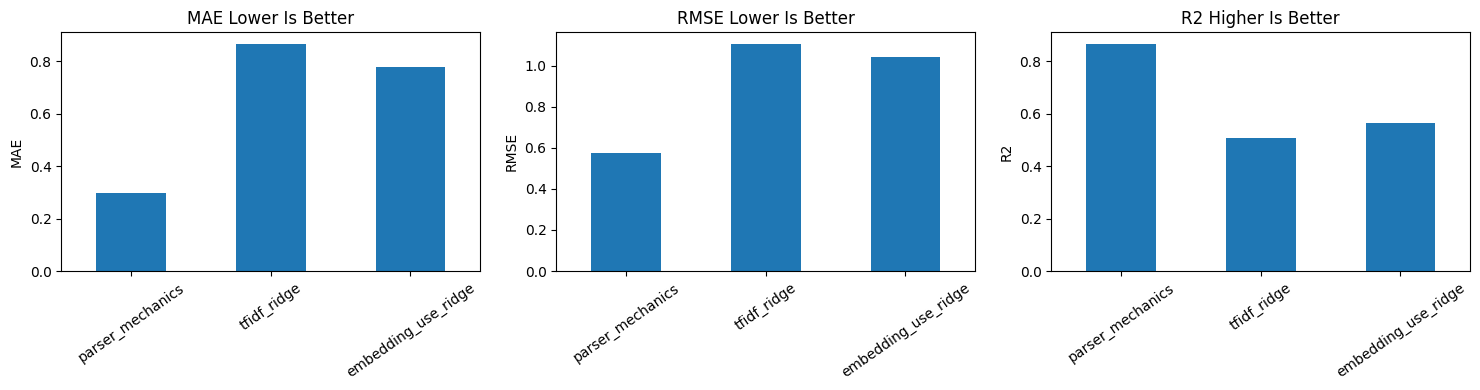

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_df.plot(kind="bar", x="model", y="mae", ax=axes[0], legend=False)
axes[0].set_title("MAE Lower Is Better")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE")

metrics_df.plot(kind="bar", x="model", y="rmse", ax=axes[1], legend=False)
axes[1].set_title("RMSE Lower Is Better")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")

metrics_df.plot(kind="bar", x="model", y="r2", ax=axes[2], legend=False)
axes[2].set_title("R2 Higher Is Better")
axes[2].set_xlabel("")
axes[2].set_ylabel("R2")

for ax in axes:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In terms of prediction error, our parser achieved an MAE of 0.30 and an RMSE of 0.58, both of which are substantially lower than those obtained using the TF-IDF and embedding-based approaches. Among the two baseline methods, the embedding model performed slightly better than TF-IDF.

Regarding model fit, our parser achieved an R² score of 0.867, indicating that it explains 86.7% of the variance in the dataset. In comparison, the TF-IDF and embedding-based models achieved R² scores of 0.51 and 0.58, respectively. Overall, these results demonstrate that the parser-based approach significantly outperforms the generic NLP baselines across all evaluation metrics.

### Residual Analysis

Residuals show where each approach over- or under-predicts `points_minus_pt`. A tighter distribution around zero indicates more consistent predictions, while wider residuals suggest mechanics or card patterns the model is not capturing well.

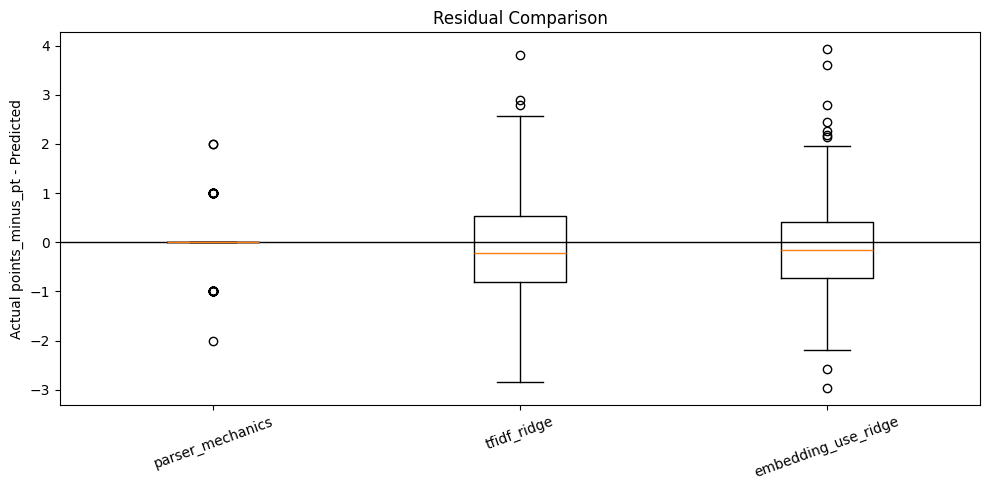

In [10]:
residuals_df = pd.DataFrame({
    "parser_mechanics": parser_test["parser_mechanics_residual"].values,
    "tfidf_ridge": tfidf_results["tfidf_residual"].values,
    "embedding_use_ridge": embedding_results["embedding_residual"].values,
})

plt.figure(figsize=(10, 5))
plt.boxplot(
    [residuals_df[col] for col in residuals_df.columns],
    tick_labels=residuals_df.columns,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Residual Comparison")
plt.ylabel("Actual points_minus_pt - Predicted")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The residual analysis further demonstrates the superiority of our parser. For the parser-based model, the residuals are centered almost perfectly around zero, with the boxplot collapsing to nearly a single line. In contrast, the residuals produced by the TF-IDF and embedding-based models are much more widely dispersed around the zero line. Moreover, their median residuals fall below zero, suggesting a systematic bias in their predictions. The tighter distribution and near-zero median of the parser's residuals indicate that it captures the underlying power structure of the cards more accurately and consistently than the generic NLP approaches. These findings provide additional evidence that the parser is more effective at modeling true card power.

### Actual vs Predicted Scores

These plots compare each model's predictions against the true `points_minus_pt` values. Points closer to the diagonal line are better predictions; points far from the line show cases where a model disagrees with the hand-scored labels.

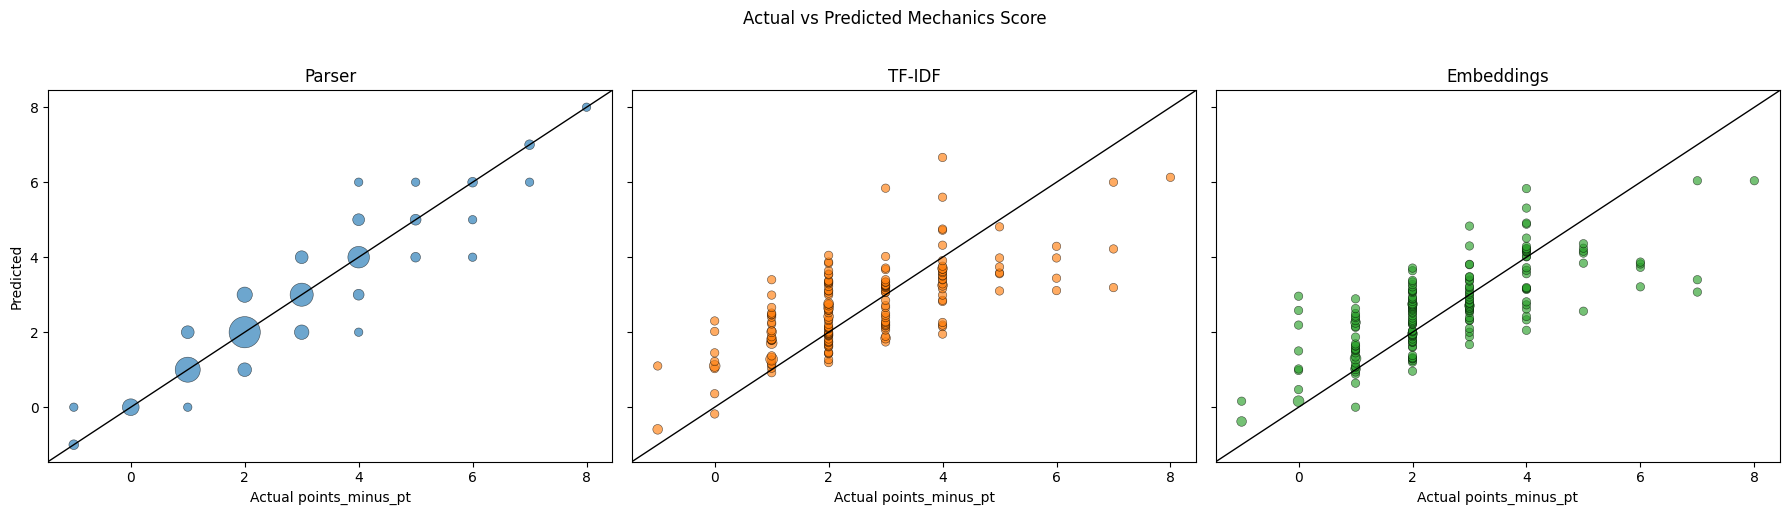

In [11]:
actual = test_df["points_minus_pt"]

model_plots = [
    ("Parser", parser_test["parser_mechanics_score"], "tab:blue"),
    ("TF-IDF", tfidf_preds, "tab:orange"),
    ("Embeddings", embedding_preds, "tab:green"),
]

min_val = min(
    actual.min(),
    parser_test["parser_mechanics_score"].min(),
    tfidf_preds.min(),
    embedding_preds.min(),
)
max_val = max(
    actual.max(),
    parser_test["parser_mechanics_score"].max(),
    tfidf_preds.max(),
    embedding_preds.max(),
)

padding = (max_val - min_val) * 0.05
axis_min = min_val - padding
axis_max = max_val + padding

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, (title, preds, color) in zip(axes, model_plots):
    plot_df = pd.DataFrame({
        "actual": actual.values,
        "predicted": np.asarray(preds),
    })

    # Keep continuous model predictions visually readable while still showing overlap.
    if title != "Parser":
        plot_df["predicted"] = plot_df["predicted"].round(2)

    counts = (
        plot_df
        .groupby(["actual", "predicted"])
        .size()
        .reset_index(name="count")
    )

    ax.scatter(
        counts["actual"],
        counts["predicted"],
        s=25 + counts["count"] * 12,
        alpha=0.65,
        color=color,
        edgecolor="black",
        linewidth=0.4,
    )

    ax.plot([axis_min, axis_max], [axis_min, axis_max], color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Actual points_minus_pt")
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

axes[0].set_ylabel("Predicted")
fig.suptitle("Actual vs Predicted Mechanics Score", y=1.02)
plt.tight_layout()
plt.show()

Marker size indicates how many cards share the same actual/predicted coordinate. This matters most for the parser because its rule-based scores are discrete, so many cards overlap exactly. The NLP baselines produce continuous predictions, which spread points across more unique coordinates.

### Largest Parser Misses

Even the parser's worst cases are small. On the held-out test set no creature is off by more than **2 points**, and most of the largest residuals miss by just 1 — consistent with the overall MAE of ~0.31. The misses also split between slight over- and under-valuations, so there is no systematic directional bias; these are edge cases, not pipeline failures.

The residuals that remain point to context the rule-based features don't yet capture. The handful of 2-point misses run in both directions — the parser overvalues a card like *Arcanis the Omnipotent* and undervalues one like *Clement, the Worrywort* — which likely reflects abilities whose practical value depends on board state, synergy, or text patterns not yet represented in the feature rules. We treat these as a targeted to-do list for future scoring refinements rather than evidence of a broken system.


In [12]:
parser_test.assign(
    abs_residual=parser_test["parser_mechanics_residual"].abs()
).sort_values("abs_residual", ascending=False)[
    [
        "name",
        "set",
        "points_minus_pt",
        "parser_mechanics_score",
        "parser_mechanics_residual",
    ]
].head(10)

,name,set,points_minus_pt,parser_mechanics_score,parser_mechanics_residual
247,Arcanis the Omnipotent,ons,4.0,6,-2.0
784,"Clement, the Worrywort",blb,6.0,4,2.0
673,Adaptive Shimmerer,iko,4.0,2,2.0
746,Plumecreed Escort,blb,4.0,3,1.0
76,Cockatrice,lea,3.0,2,1.0
213,Riptide Chronologist,ons,1.0,2,-1.0
377,Boggart Mob,lrw,4.0,5,-1.0
760,Cindering Cutthroat,blb,3.0,2,1.0
479,Abzan Falconer,ktk,4.0,3,1.0
212,Fallen Cleric,ons,3.0,4,-1.0


### Summary

On this dataset, the parser outperforms both TF-IDF and Universal Sentence Encoder baselines. This supports using a rule-based mechanics parser for *Magic: The Gathering* card text: the language is templated, semi-structured, and tightly tied to formal game rules. The remaining high-residual cases give us concrete directions for future feature and scoring improvements.

## Parser Power Score by Set and Mana Value

The previous project analyzed creature power creep by modeling hand-scored power values as a function of mana value, separately for each set. Because mana value is the primary resource cost of a creature, this view helps compare whether newer creatures are receiving more power at the same cost.

This section recreates that analysis using the automated parser scores from our current project. Instead of using the manually assigned `points` column as the target, we use `parser_total_score`, which combines the parser's power/toughness, keyword, and ability scores.

The analysis proceeds in four steps. First, we calculate the average parser score for each mana value within each set. Second, we compare those averages against Limited Edition Alpha (LEA), which serves as the historical baseline. Third, we fit polynomial regression curves for each set to summarize the relationship between mana value and parser score. Finally, we train a historical model on older sets and test it on modern sets to measure whether modern creature scores exceed what would be expected from earlier design patterns.

This gives us a direct comparison to last quarter's analysis while using the parser-generated scores that are central to this project.

Average parser total score by mana value


,LEA,ONS,LRW,KTK,IKO,BLB
cmc,,,,,,
1.0,2.92,3.93,3.60,5.00,4.40,5.54
2.0,5.09,4.93,4.97,6.28,6.80,7.11
3.0,4.93,5.36,5.94,8.13,8.07,8.43
4.0,7.00,7.71,8.98,8.58,10.30,10.31
5.0,9.15,9.00,11.00,11.27,13.60,13.06
6.0,13.27,11.55,15.08,11.65,14.89,14.67
7.0,19.00,14.00,14.86,16.00,20.67,15.00


Average parser total score change from LEA baseline


,ONS,LRW,KTK,IKO,BLB
cmc,,,,,
1.0,1.01,0.68,2.08,1.48,2.62
2.0,-0.16,-0.12,1.19,1.71,2.02
3.0,0.43,1.01,3.20,3.14,3.50
4.0,0.71,1.98,1.58,3.30,3.31
5.0,-0.15,1.85,2.12,4.45,3.91
6.0,-1.72,1.81,-1.62,1.62,1.40
7.0,-5.00,-4.14,-3.00,1.67,-4.00


Polynomial degree tuning summary


...

,LEA,ONS,LRW,KTK,IKO,BLB
cmc,,,,,,
1,3.12,3.94,3.77,5.21,4.68,5.79
2,4.30,4.78,4.66,6.21,6.41,6.90
3,5.31,5.81,6.40,7.61,8.29,8.55
4,6.74,7.17,8.72,9.22,10.44,10.53
5,9.18,9.04,11.36,10.82,12.95,12.65
6,13.22,11.59,14.05,12.22,15.94,14.70
7,19.45,14.97,16.53,13.22,19.52,16.47


Degree-3 parser curve metrics by set


,RMSE,MAE,R2
LEA,2.054,1.374,0.716
ONS,2.648,1.844,0.630
LRW,2.853,1.897,0.605
KTK,2.788,2.078,0.430
IKO,2.463,1.822,0.709
BLB,2.452,1.899,0.500


Degree-3 predicted parser score change from LEA


,ONS,LRW,KTK,IKO,BLB
cmc,,,,,
1,0.82,0.65,2.09,1.56,2.67
2,0.48,0.36,1.91,2.11,2.60
3,0.50,1.09,2.30,2.98,3.24
4,0.43,1.98,2.48,3.70,3.79
5,-0.14,2.18,1.64,3.77,3.47
6,-1.63,0.83,-1.00,2.72,1.48
7,-4.48,-2.92,-6.23,0.07,-2.98


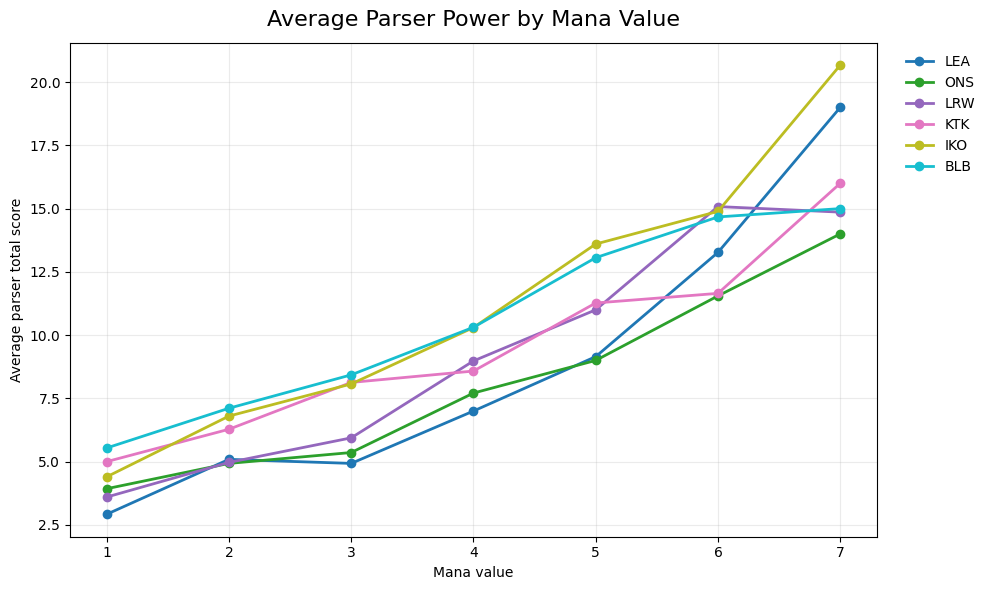

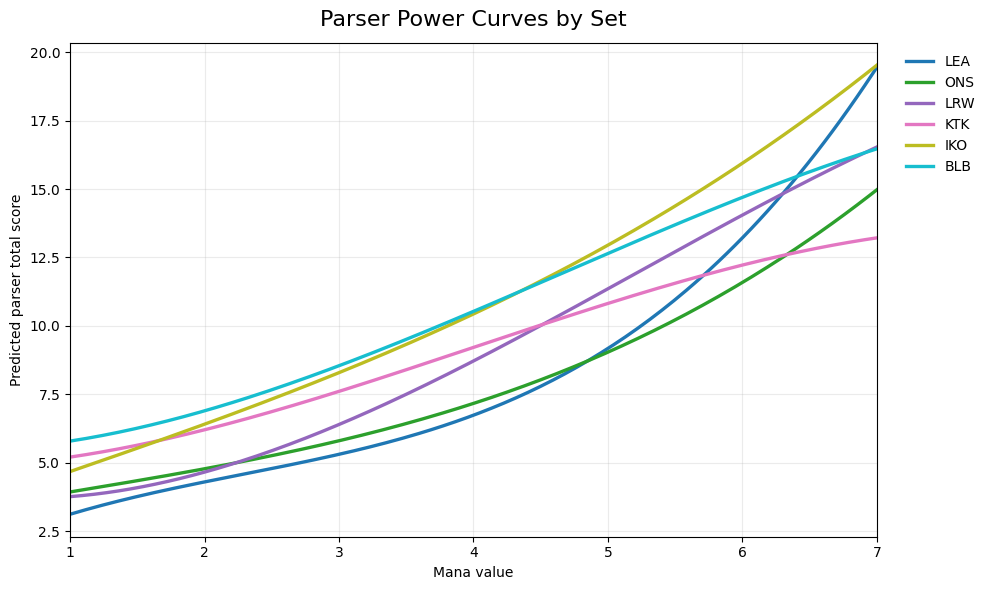

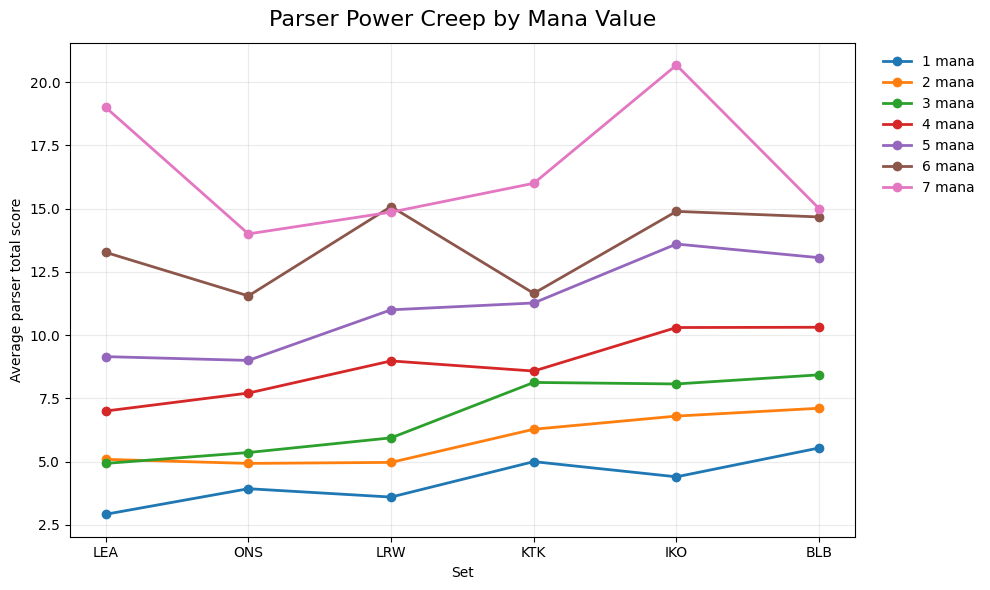

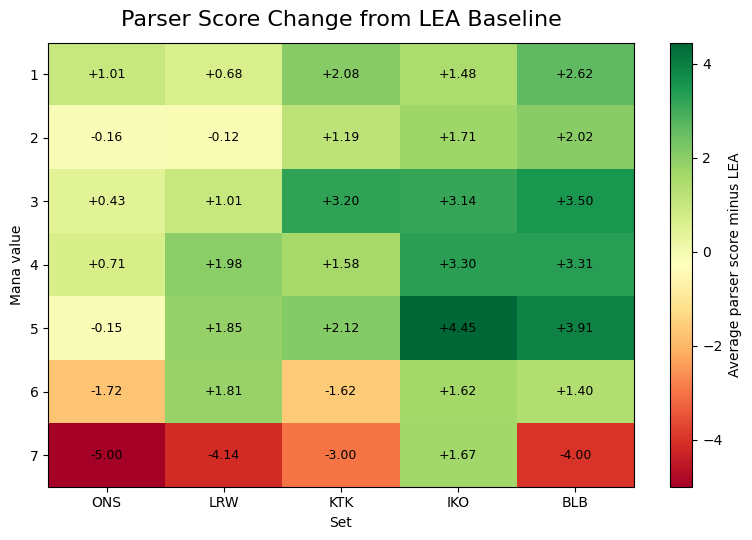

Historical model performance on modern sets


,value
RMSE,3.359
MAE,2.513
R2,0.305


Average modern residual by set


,avg_residual
set,
iko,2.21
blb,2.18


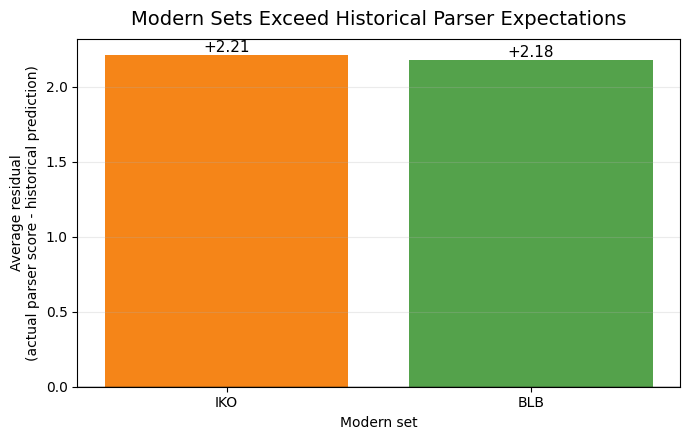

In [13]:
# Analysis: parser power score by set and mana value
# Direct analog of last quarter's analysis, but using parser_total_score instead of manual points.
# To analyze mechanics only, change TARGET_COL to "parser_mechanics_score".

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET_COL = "parser_total_score"

SET_ORDER = ["lea", "ons", "lrw", "ktk", "iko", "blb"]
SET_LABELS = [s.upper() for s in SET_ORDER]
CMC_MIN, CMC_MAX = 1, 7

parser_mana = parser_df.copy()

# parser_df is indexed by original cards_df index, so attach card metadata by lookup.
parser_mana["cmc"] = cards_df.loc[parser_mana.index, "cmc"].astype(float)
parser_mana["year"] = cards_df.loc[parser_mana.index, "year"].astype(int)
parser_mana["set_name"] = cards_df.loc[parser_mana.index, "set_name"]

parser_mana = parser_mana[parser_mana["set"].isin(SET_ORDER)].copy()
parser_mana_1_7 = parser_mana[
    parser_mana["cmc"].between(CMC_MIN, CMC_MAX)
].copy()

# Raw average parser score by set and mana value.
avg_parser_by_cmc = (
    parser_mana_1_7
    .groupby(["set", "cmc"], as_index=False)[TARGET_COL]
    .mean()
)

average_parser_table = (
    avg_parser_by_cmc
    .pivot(index="cmc", columns="set", values=TARGET_COL)
    .reindex(columns=SET_ORDER)
)
average_parser_table.columns = SET_LABELS
average_parser_table = average_parser_table.round(2)

parser_change_from_lea = (
    average_parser_table
    .subtract(average_parser_table["LEA"], axis=0)
    .drop(columns="LEA")
    .round(2)
)

print("Average parser total score by mana value")
display(average_parser_table)

print("Average parser total score change from LEA baseline")
display(parser_change_from_lea)

# Tune polynomial degree using parser score ~ mana value, separately by set.
degrees = [1, 2, 3, 4]
tuning_results = []

for degree in degrees:
    for set_code in SET_ORDER:
        subset = parser_mana[parser_mana["set"] == set_code]

        X = subset[["cmc"]]
        y = subset[TARGET_COL]

        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression(),
        )
        model.fit(X, y)
        y_pred = model.predict(X)

        tuning_results.append({
            "degree": degree,
            "set": set_code.upper(),
            "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
            "MAE": mean_absolute_error(y, y_pred),
            "R2": r2_score(y, y_pred),
        })

mana_tuning_df = pd.DataFrame(tuning_results).round(3)
mana_tuning_summary = (
    mana_tuning_df
    .groupby("degree")[["RMSE", "MAE", "R2"]]
    .mean()
    .round(3)
)

print("Polynomial degree tuning summary")
display(mana_tuning_summary)

# Match last quarter's final model: degree-3 polynomial curve per set.
cmc_plot = np.linspace(CMC_MIN, CMC_MAX, 200)
cmc_plot_df = pd.DataFrame({"cmc": cmc_plot})

cmc_table = np.arange(CMC_MIN, CMC_MAX + 1)
cmc_table_df = pd.DataFrame({"cmc": cmc_table})

curve_models = {}
curve_predictions_plot = {}
curve_predictions_table = {}
curve_scores = {}
curve_residual_rows = []

for set_code in SET_ORDER:
    subset = parser_mana[parser_mana["set"] == set_code].copy()

    X = subset[["cmc"]]
    y = subset[TARGET_COL]

    model = make_pipeline(
        PolynomialFeatures(3, include_bias=False),
        LinearRegression(),
    )
    model.fit(X, y)

    y_pred = model.predict(X)
    subset["predicted_parser_total"] = y_pred
    subset["parser_curve_residual"] = y - y_pred

    curve_models[set_code.upper()] = model
    curve_predictions_plot[set_code.upper()] = model.predict(cmc_plot_df)
    curve_predictions_table[set_code.upper()] = model.predict(cmc_table_df)
    curve_residual_rows.append(subset)

    curve_scores[set_code.upper()] = {
        "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
        "MAE": mean_absolute_error(y, y_pred),
        "R2": r2_score(y, y_pred),
    }

parser_curve_expected_table = (
    pd.DataFrame(curve_predictions_table, index=cmc_table)
    .round(2)
)
parser_curve_expected_table.index.name = "cmc"

parser_curve_scores_df = pd.DataFrame(curve_scores).T.round(3)
parser_curve_residuals_df = pd.concat(curve_residual_rows)

parser_curve_change_from_lea = (
    parser_curve_expected_table
    .subtract(parser_curve_expected_table["LEA"], axis=0)
    .drop(columns="LEA")
    .round(2)
)

print("Degree-3 predicted parser power score by mana value")
display(parser_curve_expected_table)

print("Degree-3 parser curve metrics by set")
display(parser_curve_scores_df)

print("Degree-3 predicted parser score change from LEA")
display(parser_curve_change_from_lea)

# Plot 1: raw averages by mana value.
colors = plt.cm.tab10(np.linspace(0, 1, len(SET_ORDER)))

fig, ax = plt.subplots(figsize=(10, 6))

for i, set_label in enumerate(SET_LABELS):
    ax.plot(
        average_parser_table.index,
        average_parser_table[set_label],
        marker="o",
        linewidth=2,
        color=colors[i],
        label=set_label,
    )

ax.set_title("Average Parser Power by Mana Value", fontsize=16, pad=12)
ax.set_xlabel("Mana value")
ax.set_ylabel("Average parser total score")
ax.set_xticks(cmc_table)
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

# Plot 2: fitted power curves by set.
fig, ax = plt.subplots(figsize=(10, 6))

for i, set_label in enumerate(SET_LABELS):
    ax.plot(
        cmc_plot,
        curve_predictions_plot[set_label],
        linewidth=2.4,
        color=colors[i],
        label=set_label,
    )

ax.set_title("Parser Power Curves by Set", fontsize=16, pad=12)
ax.set_xlabel("Mana value")
ax.set_ylabel("Predicted parser total score")
ax.set_xlim(CMC_MIN, CMC_MAX)
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

# Plot 3: power creep over time, one line per mana value.
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(SET_ORDER))

for cmc in cmc_table:
    y = average_parser_table.loc[float(cmc), SET_LABELS]
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=f"{cmc} mana",
    )

ax.set_title("Parser Power Creep by Mana Value", fontsize=16, pad=12)
ax.set_xlabel("Set")
ax.set_ylabel("Average parser total score")
ax.set_xticks(x)
ax.set_xticklabels(SET_LABELS)
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

# Plot 4: heatmap of change from LEA baseline.
fig, ax = plt.subplots(figsize=(8, 5.5))

heat_data = parser_change_from_lea.to_numpy()
im = ax.imshow(heat_data, cmap="RdYlGn", aspect="auto")

ax.set_title("Parser Score Change from LEA Baseline", fontsize=16, pad=12)
ax.set_xlabel("Set")
ax.set_ylabel("Mana value")
ax.set_xticks(np.arange(parser_change_from_lea.shape[1]))
ax.set_xticklabels(parser_change_from_lea.columns)
ax.set_yticks(np.arange(parser_change_from_lea.shape[0]))
ax.set_yticklabels([int(c) for c in parser_change_from_lea.index])

for row in range(parser_change_from_lea.shape[0]):
    for col in range(parser_change_from_lea.shape[1]):
        value = parser_change_from_lea.iloc[row, col]
        ax.text(col, row, f"{value:+.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Average parser score minus LEA")
fig.tight_layout()
plt.show()

# Historical-to-modern residual analysis, matching last quarter's predictive framing.
train_sets = ["lea", "ons", "lrw", "ktk"]
test_sets = ["iko", "blb"]

train_df_curve = parser_mana[parser_mana["set"].isin(train_sets)].copy()
test_df_curve = parser_mana[parser_mana["set"].isin(test_sets)].copy()

X_train = train_df_curve[["cmc"]]
y_train = train_df_curve[TARGET_COL]
X_test = test_df_curve[["cmc"]]
y_test = test_df_curve[TARGET_COL]

historical_model = make_pipeline(
    PolynomialFeatures(2, include_bias=False),
    LinearRegression(),
)
historical_model.fit(X_train, y_train)

modern_pred = historical_model.predict(X_test)

historical_model_scores = {
    "RMSE": np.sqrt(mean_squared_error(y_test, modern_pred)),
    "MAE": mean_absolute_error(y_test, modern_pred),
    "R2": r2_score(y_test, modern_pred),
}

modern_residuals = test_df_curve.copy()
modern_residuals["historical_model_prediction"] = modern_pred
modern_residuals["historical_model_residual"] = (
    modern_residuals[TARGET_COL] - modern_residuals["historical_model_prediction"]
)

average_modern_residual = (
    modern_residuals
    .groupby("set")["historical_model_residual"]
    .mean()
    .reindex(test_sets)
    .round(2)
)

print("Historical model performance on modern sets")
display(pd.Series(historical_model_scores).round(3).to_frame("value"))

print("Average modern residual by set")
display(average_modern_residual.to_frame("avg_residual"))

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(
    [s.upper() for s in test_sets],
    average_modern_residual.values,
    color=["#f58518", "#54a24b"],
)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Modern Sets Exceed Historical Parser Expectations", fontsize=14, pad=10)
ax.set_xlabel("Modern set")
ax.set_ylabel("Average residual\n(actual parser score - historical prediction)")
ax.grid(axis="y", alpha=0.25)

for i, value in enumerate(average_modern_residual.values):
    ax.text(i, value, f"{value:+.2f}", ha="center", va="bottom", fontsize=11)

fig.tight_layout()
plt.show()

### Interpretation

The parser-based mana-value analysis shows the same broad pattern found in the previous hand-scored project: modern creature sets tend to have higher power scores than early sets at the same mana value. This is especially visible at low and mid mana values, where additional abilities and keywords have a larger relative impact on a card's total score.

The LEA-baseline comparison shows that Ikoria and Bloomburrow are consistently above the 1993 baseline from one through five mana. In the fitted degree-3 table, Bloomburrow is approximately 2.67 points above LEA at one mana, 2.60 points above at two mana, 3.24 points above at three mana, 3.79 points above at four mana, and 3.47 points above at five mana. Ikoria follows a similar pattern, especially from two through six mana. These differences suggest that modern creatures are not merely stronger in aggregate; they are stronger at comparable resource costs.

The high-mana results are less stable. Mana values six and seven contain fewer creatures, so the averages and fitted curves are more sensitive to individual outliers. This is consistent with the previous project, where higher mana values also showed more variance and weaker trend clarity.

The historical model provides another way to frame the same result. When trained only on older sets and evaluated on modern sets, the model underpredicts modern parser scores by about 2.21 points for Ikoria and 2.18 points for Bloomburrow. In other words, modern creatures score roughly two points higher than expected based on historical mana-value patterns.

Overall, this analysis supports the conclusion that creature power creep appears at comparable mana values, particularly in efficient low- and mid-cost creatures. The component analysis below helps explain why: much of the increase comes from keywords and rules-text abilities rather than raw power and toughness alone.

## Power Creep Over Time

The mana-value analysis above compares creatures at similar resource costs, which helps show where power creep appears within comparable card designs. In this section, we zoom back out and ask a broader longitudinal question: **how have average creature power scores changed across *Magic*'s history?**

We reuse the same parser output from `parser_df`, attach each scored creature's release year from the cleaned dataset, and average the parser's total and component scores by year. This gives us a year-level view of power creep across the sampled sets. The hand-scored `points` column is also included as an external check that the parser's trend follows the same general pattern as human scoring.

Together, the mana-value and year-level analyses answer related but distinct questions. The mana-value section asks whether newer creatures are stronger at comparable costs, while this section asks whether the overall average score rises across release years and which score components drive that rise.

> All values below are recomputed live from the current parser, so they may differ slightly from earlier presentation figures. The shape of the trend is more important than exact point estimates.

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# parser_df is indexed by the original cards_df row index, so the year join is a lookup.
parser_df["year"] = cards_df.loc[parser_df.index, "year"].astype(int)

# Average the parser + hand scores per release year.
yearly = parser_df.groupby("year", as_index=False).agg(
    n_cards=("oracle_id", "count"),
    total=("parser_total_score", "mean"),
    pt=("parser_pt_score", "mean"),
    keyword=("parser_keyword_score", "mean"),
    ability=("parser_ability_score", "mean"),
    mechanics=("parser_mechanics_score", "mean"),
    manual=("manual_points", "mean"),
)

first_year, last_year = int(yearly["year"].min()), int(yearly["year"].max())


def fit_curve(x, y, degree=3, n=200):
    """Degree-3 polynomial trend, matching the original power-creep analysis."""
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    model.fit(x.reshape(-1, 1), y)
    grid = np.linspace(x.min(), x.max(), n)
    return grid, model.predict(grid.reshape(-1, 1))


def year_delta(col):
    a = yearly.loc[yearly["year"] == first_year, col].iloc[0]
    b = yearly.loc[yearly["year"] == last_year, col].iloc[0]
    return a, b, b - a


component_colors = {
    "total": "#1f77b4",
    "manual": "#6f6f6f",
    "pt": "#4c78a8",
    "keyword": "#f58518",
    "ability": "#54a24b",
}

yearly.round(2)


,year,n_cards,total,pt,keyword,ability,mechanics,manual
0,1993,92,6.82,5.61,0.35,0.86,1.21,6.76
1,2002,174,7.85,5.63,0.67,1.56,2.22,7.87
2,2007,169,8.07,5.47,0.76,1.84,2.60,7.94
3,2014,121,9.03,6.43,1.01,1.60,2.60,9.03
4,2020,138,9.79,6.74,0.99,2.07,3.05,9.79
5,2024,163,9.00,5.66,1.18,2.16,3.34,9.15


### Average parser power score over time

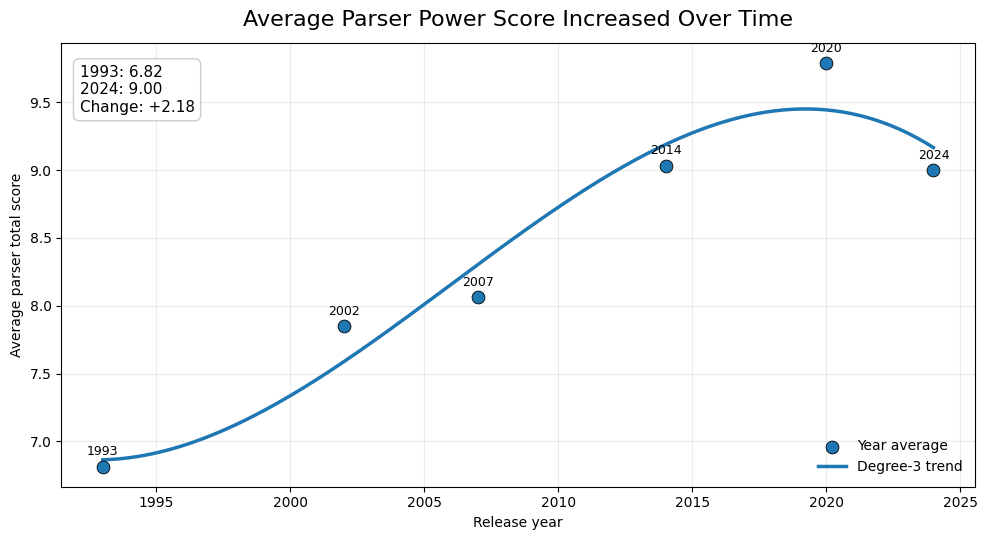

In [15]:
x = yearly["year"].to_numpy()
y = yearly["total"].to_numpy()
grid, pred = fit_curve(x, y)
first_val, last_val, change = year_delta("total")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(x, y, s=85, color=component_colors["total"], edgecolor="black",
           linewidth=0.6, label="Year average", zorder=3)
ax.plot(grid, pred, color=component_colors["total"], linewidth=2.5, label="Degree-3 trend")
for _, r in yearly.iterrows():
    ax.annotate(str(int(r["year"])), (r["year"], r["total"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

ax.set_title("Average Parser Power Score Increased Over Time", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average parser total score")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
ax.text(0.02, 0.95,
        f"{first_year}: {first_val:.2f}\n{last_year}: {last_val:.2f}\nChange: {change:+.2f}",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.4"))
fig.tight_layout()
plt.show()


The parser's year-level analysis shows a clear increase in average creature power across the sampled sets. The average parser score rises from 6.82 in 1993 to 9.00 in 2024, a gain of 2.18 points across the period.

The highest average score appears in 2020, where Ikoria reaches 9.79. The 2024 Bloomburrow average is lower at 9.00, but it remains well above the 1993 baseline. Because this analysis uses one sampled set per selected year, the dip from 2020 to 2024 should be interpreted cautiously: it may reflect differences between these specific sets rather than a definitive reversal in long-term power creep.

### Power creep by component

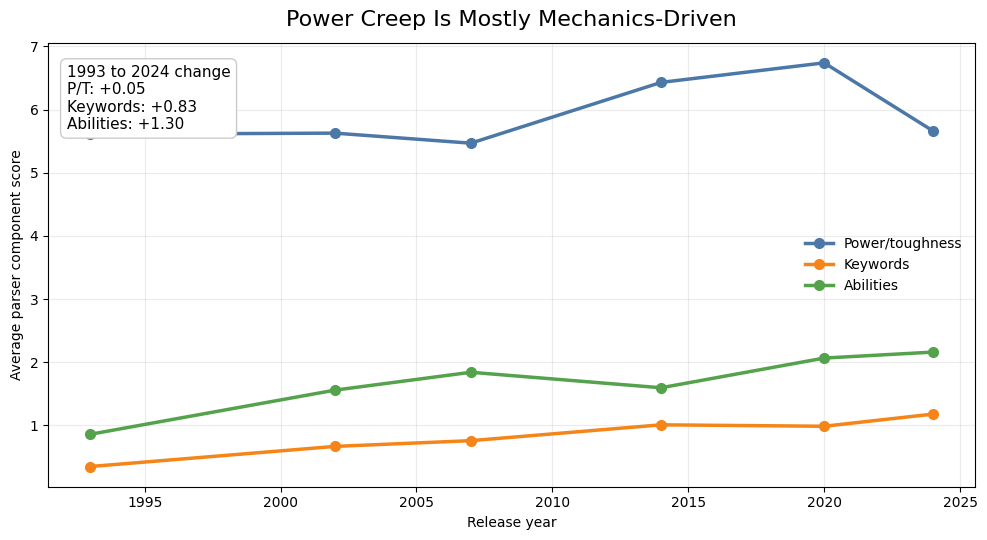

In [16]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for col, label in [("pt", "Power/toughness"), ("keyword", "Keywords"), ("ability", "Abilities")]:
    ax.plot(yearly["year"], yearly[col], marker="o", linewidth=2.5, markersize=7,
            color=component_colors[col], label=label)

d_pt = year_delta("pt")[2]
d_kw = year_delta("keyword")[2]
d_ab = year_delta("ability")[2]

ax.set_title("Power Creep Is Mostly Mechanics-Driven", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average parser component score")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
ax.text(0.02, 0.95,
        f"{first_year} to {last_year} change\nP/T: {d_pt:+.2f}\n"
        f"Keywords: {d_kw:+.2f}\nAbilities: {d_ab:+.2f}",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.4"))
fig.tight_layout()
plt.show()


To identify the sources of power creep, we decomposed the overall parser score into three components: power/toughness, keywords, and abilities. From 1993 to 2024, the average power/toughness score increased by only 0.05 points, which is effectively flat. In contrast, keyword scores increased by 0.83 points, while ability scores increased by 1.30 points.

These results suggest that the observed increase in creature power is primarily mechanics-driven. Rather than simply becoming larger, newer creatures tend to gain more value through keyword abilities and rules-text effects.

The 2020 set shows a noticeable spike in power/toughness, which contributes to its high overall score. However, because the dataset samples one set per selected year, this should be interpreted as a set-level observation rather than proof of a broad design-policy shift.

### Component composition by year

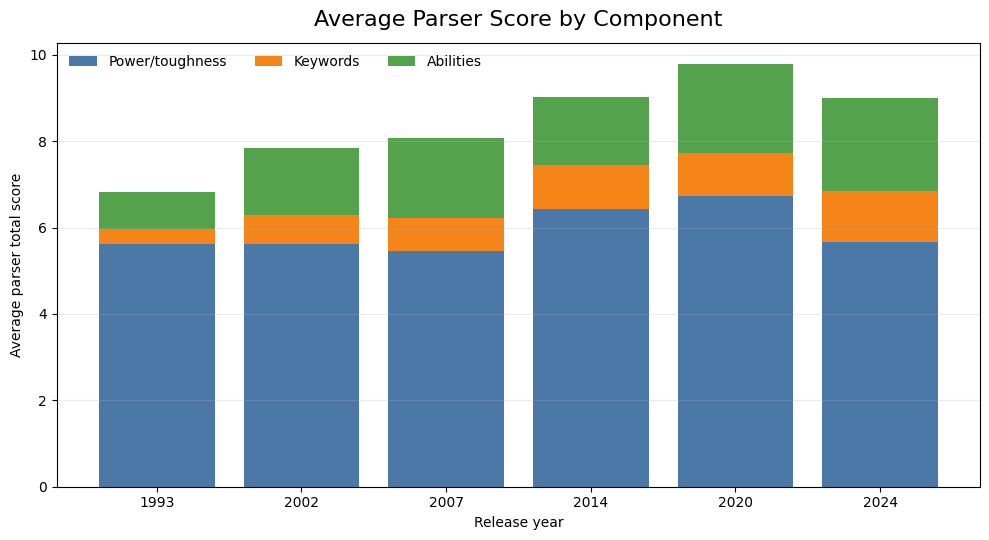

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(yearly))
for col, label in [("pt", "Power/toughness"), ("keyword", "Keywords"), ("ability", "Abilities")]:
    ax.bar(yearly["year"].astype(str), yearly[col], bottom=bottom,
           color=component_colors[col], label=label)
    bottom += yearly[col].to_numpy()

ax.set_title("Average Parser Score by Component", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average parser total score")
ax.legend(frameon=False, ncols=3, loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


The component composition reinforces the same pattern. Raw power and toughness remain relatively stable across the sampled years, increasing from 5.61 in 1993 to 5.66 in 2024.

Keyword and ability scores grow much more substantially. Average keyword score rises from 0.35 to 1.18, while average ability score rises from 0.86 to 2.16. In raw point terms, ability score contributes the largest increase.

In practical terms, modern creatures are not just larger bodies. They more often include relevant keywords, triggered abilities, card advantage, token creation, removal, or other rules-text effects that add value beyond combat stats.

### Parser trend vs hand-scored trend

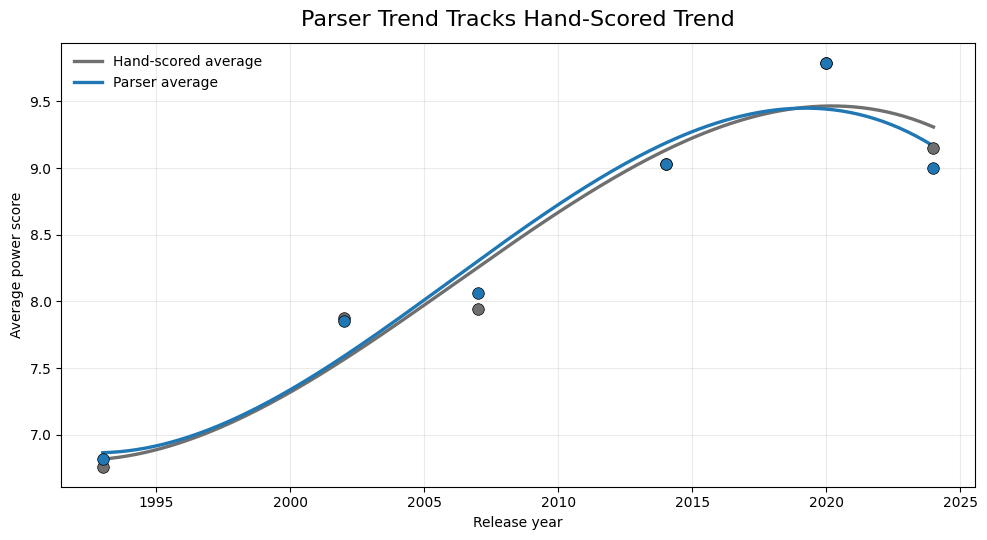

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for col, label in [("manual", "Hand-scored average"), ("total", "Parser average")]:
    grid, pred = fit_curve(x, yearly[col].to_numpy())
    ax.scatter(yearly["year"], yearly[col], s=70, color=component_colors[col],
               edgecolor="black", linewidth=0.5, zorder=3)
    ax.plot(grid, pred, linewidth=2.4, color=component_colors[col], label=label)

ax.set_title("Parser Trend Tracks Hand-Scored Trend", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average power score")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


To validate the parser's longitudinal results, we compare parser-generated yearly averages against the existing hand-scored `points` values in the curated dataset. The two trends closely align across the sampled years, suggesting that the parser is recovering the same broad pattern as the manual scoring process.

This is important because the parser is not merely producing isolated per-card scores; it also preserves the historical trend present in the human-scored data. That agreement supports using the automated scores for larger-scale analysis, while still acknowledging that individual cards may be over- or under-scored in edge cases.

**Reading the trend.** Average parser power rises from the game's earliest sets through the 2010s before flattening in the most recent years — the same arc the hand scores show, which is reassuring evidence that the rule-based parser tracks real design change rather than a scoring artifact. Decomposing the score shows the increase is **mechanics-driven**: raw power/toughness is nearly flat across three decades, while the *abilities* and *keywords* components account for almost all of the growth. Newer creatures aren't bigger so much as they *do more*.


## Limitations

That being said, there are some limitations in our analysis. 

1. Curated Creature Dataset Rather Than the Entire Card Pool

    This study focuses exclusively on creature cards rather than the complete population of Magic: The Gathering cards. While creatures constitute one of the largest and most important card categories in the game, they do not fully represent the broader design landscape. Other card types, such as instants, sorceries, enchantments, and planeswalkers, may exhibit different power-creep patterns and design trends.

2. Manual Scoring Criteria Define the Target Variable

    Although the parser automates the evaluation process, the underlying definition of “power” is still derived from manually designed scoring criteria. The weights assigned to keywords, abilities, and other card attributes reflect human judgment and may not perfectly capture how players perceive card strength in actual gameplay.

3. The Parser Does Not Capture Every Edge Case

    Our rule-based parser doesn't catch every ability. Some edge cases, unusual wordings, or newly introduced mechanics slip through.

4. The Polynomial Trend Is Descriptive Rather Than Causal

    The polynomial trend line is intended to summarize and visualize long-term patterns in the data rather than establish causal relationships. Although the observed increase in card power suggests that creature design has evolved over time, the trend itself does not explain why these changes occurred.

5. Parser scores may be inflated due to non-scoring text

    Oracle text often contains descriptive or contextual language that does not directly contribute to card power. While human evaluators can distinguish such text intuitively, the parser relies on predefined rules and may occasionally assign scores to non-scoring text. As a result, some cards may receive slightly inflated power scores. Although this does not invalidate our findings, absolute scores should be interpreted with this limitation in mind.

6. Small Samples at High Mana Values

    The mana-value analysis is less stable at six and seven mana because there are fewer creatures in those buckets. A small number of unusual cards can strongly affect averages and fitted curves at high mana values.

7. Sampled Sets Rather Than Continuous Yearly Coverage

    The temporal analysis uses six representative sets rather than every set released across Magic's history. This makes the broad trend informative, but individual year-to-year changes should be interpreted as comparisons between sampled sets rather than a continuous historical time series.

## Conclusions

- Key takeaways:

    1. We developed a rule-based parser to quantify the power level of creature cards in *Magic: The Gathering*. The parser is designed to process oracle text, which is templated, semi-structured, and often too complex for generic NLP approaches to interpret effectively.

    2. Using the parser, we found clear evidence that creature power has increased over time, supporting the existence of power creep in *Magic: The Gathering*.
    
    3. The mana-value analysis shows that modern sets score higher than LEA at comparable costs, especially from one through five mana. This suggests that power creep is not only an aggregate year-level trend, but also appears when comparing creatures with similar resource costs.

    4. Our analysis suggests that power creep is primarily mechanic-driven. Increases in power are largely attributable to more numerous and more powerful keywords and abilities rather than increases in raw power and toughness.

    5. The domain-specific parser substantially outperformed generic NLP baselines, including TF-IDF and embedding-based approaches, demonstrating the value of incorporating game-specific knowledge when analyzing oracle text.


- Contributions:

    1. Quantification of Power Creep: Most research and analysis of MTG is qualitative due to the game's semi-structured card text. Our methods provide a way to quantify power score and power creep in MTG.

    2. Novel Methodology: Domain-Specific Parser: Developed a rule-based parser that successfully extracts structured features from Magic's oracle text. Demonstrated that domain-specific parsing (R² 0.867) significantly outperforms generic NLP approaches (TF-IDF 0.508, Embeddings 0.566).

    3. Design Philosophy Insight: Revealed that power creep is primarily mechanics-driven. From 1993 to 2024, power/toughness increased by only 0.05 points, while keyword score increased by 0.83 and ability score increased by 1.30. This challenges simplistic assumptions that creature power creep is mainly stat-driven.

    4. Built a generalizable parser pipeline that could be applied to other card games (Yu-Gi-Oh, Pokémon TCG), card design recommendations, game balance analysis.
    